# **Data Cleaning**

**Q1. Missing Data Identification
Scenario:
The hospital suspects incomplete patient records.Task:
Identify missing values in each column
Calculate percentage of missing data**

In [1]:
from google.colab import files
uploaded = files.upload()

Saving healthcare_data_cleaning_dataset.csv to healthcare_data_cleaning_dataset.csv


In [2]:
import pandas as pd

df = pd.read_csv("healthcare_data_cleaning_dataset.csv")
print(df.head())

   Patient_ID   Age  Gender       City     Diagnosis  Hospital_Visits  \
0       17270  35.0    Male  Bangalore  Hypertension               13   
1       10860  21.0  Female  Hyderabad           Flu               11   
2       15390  77.0  Female  Bangalore        Asthma                2   
3       15191  79.0  Female     Mumbai        Asthma               13   
4       15734  60.0  Female      Delhi        Asthma                1   

   Treatment_Cost  Insurance_Coverage Admission_Date  
0         41010.0                   1     2023-11-30  
1         12194.0                   1     2023-02-23  
2         45086.0                   0     2023-03-14  
3         40842.0                   0     2023-08-01  
4          9873.0                   1     2023-06-20  


In [3]:
import pandas as pd

# Missing values count
missing_values = df.isnull().sum()

# Missing percentage
missing_percentage = (missing_values / len(df)) * 100

# Combine results
missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage Missing (%)": missing_percentage
})

print(missing_summary)

                    Missing Values  Percentage Missing (%)
Patient_ID                       0                0.000000
Age                            600               11.764706
Gender                           0                0.000000
City                             0                0.000000
Diagnosis                        0                0.000000
Hospital_Visits                  0                0.000000
Treatment_Cost                 593               11.627451
Insurance_Coverage               0                0.000000
Admission_Date                   0                0.000000


**Q2. Handling Missing Age Scenario:
Age is critical for medical analysis, but some values are missing.
Task:
Replace missing Age values with an appropriate method
Justify your choice (mean/median)**

In [4]:
import pandas as pd

# Check missing values before imputation
print("Missing Age values before:", df['Age'].isnull().sum())

# Calculate median age
median_age = df['Age'].median()

# Replace missing Age values with median
df['Age'].fillna(median_age, inplace=True)

# Check missing values after imputation
print("Missing Age values after:", df['Age'].isnull().sum())

# Display median used
print("Median Age used:", median_age)

Missing Age values before: 600
Missing Age values after: 0
Median Age used: 50.0


/tmp/ipykernel_2564/122389098.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(median_age, inplace=True)


In [5]:
df['Age'].isnull().sum()

np.int64(0)

**Q3. Handling Missing Treatment Cost
Scenario:
Treatment cost is highly skewed due to expensive treatments.
Task:
Handle missing Treatment_Cost values
Choose the correct imputation method and explain why**

In [6]:
import pandas as pd

# Load dataset
df = pd.read_csv("healthcare_data_cleaning_dataset.csv")

# Check missing values before imputation
print("Missing Treatment_Cost values before:",
      df['Treatment_Cost'].isnull().sum())

# Calculate median treatment cost
median_cost = df['Treatment_Cost'].median()

# Replace missing values
df['Treatment_Cost'].fillna(median_cost, inplace=True)

# Check missing values after imputation
print("Missing Treatment_Cost values after:",
      df['Treatment_Cost'].isnull().sum())

# Display median used
print("Median Treatment Cost used:", median_cost)

Missing Treatment_Cost values before: 593
Missing Treatment_Cost values after: 0
Median Treatment Cost used: 24797.0


/tmp/ipykernel_2564/4130993200.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Treatment_Cost'].fillna(median_cost, inplace=True)


In [7]:
df['Treatment_Cost'].isnull().sum()

np.int64(0)

**Q4. Duplicate Patient Records
Scenario:
Some patient records were entered multiple times.
Task:
Identify duplicate rows
Remove duplicates
Compare dataset size before and after**

In [8]:
# Identify Duplicate Rows

import pandas as pd

# Count duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 99


In [9]:
# Remove Duplicate Rows

# Dataset size before removing duplicates
before_rows = len(df)

# Remove duplicates
df_clean = df.drop_duplicates()

# Dataset size after removing duplicates
after_rows = len(df_clean)

print("Rows before removing duplicates:", before_rows)
print("Rows after removing duplicates:", after_rows)
print("Duplicates removed:", before_rows - after_rows)

Rows before removing duplicates: 5100
Rows after removing duplicates: 5001
Duplicates removed: 99


In [10]:
# Compare Dataset Size Before and After

comparison = pd.DataFrame({
    "Metric": ["Rows Before", "Rows After", "Duplicates Removed"],
    "Value": [before_rows, after_rows, before_rows - after_rows]
})

print(comparison)

               Metric  Value
0         Rows Before   5100
1          Rows After   5001
2  Duplicates Removed     99


**Q5. Invalid Age Values (Data Quality Check)
Scenario:
Some patients have unrealistic age values (e.g., >100 or <0).
Task:
Detect such records
Decide whether to remove or correct them**

In [12]:
# Detect Invalid Age Values

#Assume valid ages should be between 0 and 100 years.

import pandas as pd

# Load dataset
df = pd.read_csv("healthcare_data_cleaning_dataset.csv")

# Find invalid ages
invalid_age_records = df[(df['Age'] < 0) | (df['Age'] > 100)]

print("Number of invalid age records:", len(invalid_age_records))

# Display invalid records
print(invalid_age_records)

Number of invalid age records: 0
Empty DataFrame
Columns: [Patient_ID, Age, Gender, City, Diagnosis, Hospital_Visits, Treatment_Cost, Insurance_Coverage, Admission_Date]
Index: []


In [13]:
# Count Invalid Records

invalid_count = ((df['Age'] < 0) | (df['Age'] > 100)).sum()

print("Invalid Age Count:", invalid_count)

Invalid Age Count: 0


In [14]:
# Decide How to Handle Them

df_clean = df[(df['Age'] >= 0) & (df['Age'] <= 100)]

print("Rows after removing invalid ages:", len(df_clean))

Rows after removing invalid ages: 4500


**Q6. Outlier Detection (Treatment Cost)
Scenario:
Extreme treatment costs are affecting analysis.
Task:
Detect outliers using IQR method
Display number of outliers**

In [15]:
# Calculate IQR

import pandas as pd

# Calculate Q1 and Q3
Q1 = df['Treatment_Cost'].quantile(0.25)
Q3 = df['Treatment_Cost'].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 12498.0
Q3: 37922.0
IQR: 25424.0


In [16]:
# Calculate Outlier Boundaries

# Lower and Upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -25638.0
Upper Bound: 76058.0


In [17]:
# Detect Outliers

# Find outliers
outliers = df[
    (df['Treatment_Cost'] < lower_bound) |
    (df['Treatment_Cost'] > upper_bound)
]

print("Number of outliers:", len(outliers))

# Display first few outliers
print(outliers.head())

Number of outliers: 50
     Patient_ID   Age  Gender       City     Diagnosis  Hospital_Visits  \
53        13152  91.0  Female    Chennai      COVID-19               13   
86        10064  28.0  Female  Hyderabad  Hypertension               16   
124       17035  59.0    Male      Delhi           Flu                9   
183       15855  36.0    Male     Mumbai      Diabetes                1   
215       19561  29.0    Male     Mumbai           Flu               16   

     Treatment_Cost  Insurance_Coverage Admission_Date  
53    199702.965333                   0     2023-01-24  
86    199702.965333                   0     2023-02-18  
124   199702.965333                   0     2023-04-27  
183   199702.965333                   0     2023-01-16  
215   199702.965333                   0     2023-05-31  


In [18]:
# Display Outlier Count Only

outlier_count = (
    (df['Treatment_Cost'] < lower_bound) |
    (df['Treatment_Cost'] > upper_bound)
).sum()

print("Total Outliers:", outlier_count)

Total Outliers: 50


**Q7. Outlier Treatment
Scenario:
The business team wants to retain all records.
Task:
Apply capping (Winsorization) on Treatment_Cost
Use 5th and 95th percentile**

In [19]:
# Calculate the 5th and 95th Percentiles

import pandas as pd

# Load dataset
df = pd.read_csv("healthcare_data_cleaning_dataset.csv")

# Calculate percentiles
lower_cap = df['Treatment_Cost'].quantile(0.05)
upper_cap = df['Treatment_Cost'].quantile(0.95)

print("5th Percentile:", lower_cap)
print("95th Percentile:", upper_cap)

5th Percentile: 2914.6
95th Percentile: 48188.1


In [20]:
# Apply Winsorization (Capping)

# Create a capped version of Treatment_Cost
df['Treatment_Cost_Capped'] = df['Treatment_Cost'].clip(
    lower=lower_cap,
    upper=upper_cap
)

print(df[['Treatment_Cost', 'Treatment_Cost_Capped']].head())

   Treatment_Cost  Treatment_Cost_Capped
0         41010.0                41010.0
1         12194.0                12194.0
2         45086.0                45086.0
3         40842.0                40842.0
4          9873.0                 9873.0


In [21]:
# Verify the New Range

print("Minimum after capping:",
      df['Treatment_Cost_Capped'].min())

print("Maximum after capping:",
      df['Treatment_Cost_Capped'].max())

Minimum after capping: 2914.6
Maximum after capping: 48188.1


**Q8. Transformation
Scenario:
Treatment cost is highly skewed.
Task:
Apply log transformation
Create a new column
Compare before vs after distribution**

In [22]:
# Create a Log-Transformed Column

import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("healthcare_data_cleaning_dataset.csv")

# Create log-transformed column
df['Log_Treatment_Cost'] = np.log1p(df['Treatment_Cost'])

# View results
print(df[['Treatment_Cost', 'Log_Treatment_Cost']].head())

   Treatment_Cost  Log_Treatment_Cost
0         41010.0           10.621596
1         12194.0            9.408781
2         45086.0           10.716349
3         40842.0           10.617491
4          9873.0            9.197660


In [23]:
# Compare Summary Statistics

print("Original Treatment Cost")
print(df['Treatment_Cost'].describe())

print("\nLog Transformed Treatment Cost")
print(df['Log_Treatment_Cost'].describe())

Original Treatment Cost
count      4507.000000
mean      26920.151157
std       23224.930985
min         526.000000
25%       12498.000000
50%       24797.000000
75%       37922.000000
max      199702.965333
Name: Treatment_Cost, dtype: float64

Log Transformed Treatment Cost
count    4507.000000
mean        9.878058
std         0.914197
min         6.267201
25%         9.433404
50%        10.118518
75%        10.543313
max        12.204591
Name: Log_Treatment_Cost, dtype: float64


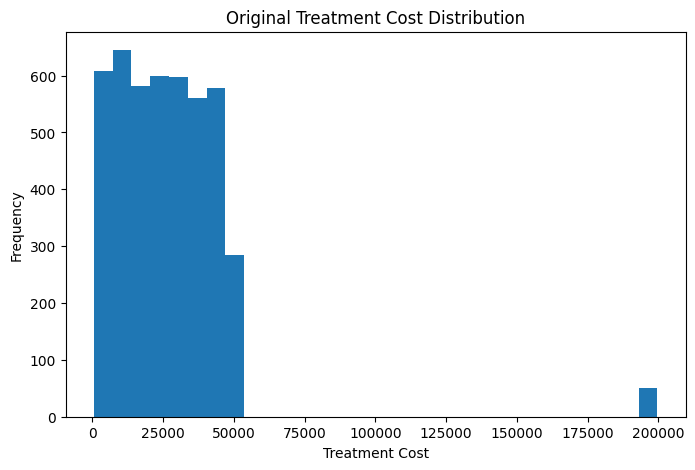

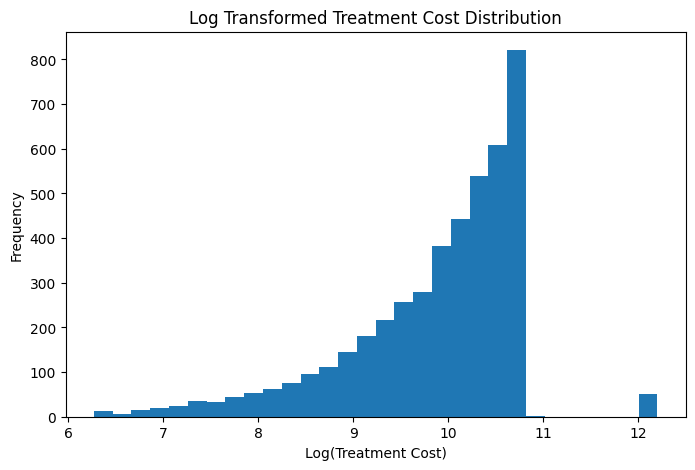

In [24]:
# Compare Distributions Visually

import matplotlib.pyplot as plt

# Original Distribution
plt.figure(figsize=(8,5))
plt.hist(df['Treatment_Cost'].dropna(), bins=30)
plt.title('Original Treatment Cost Distribution')
plt.xlabel('Treatment Cost')
plt.ylabel('Frequency')
plt.show()

# Log-Transformed Distribution
plt.figure(figsize=(8,5))
plt.hist(df['Log_Treatment_Cost'].dropna(), bins=30)
plt.title('Log Transformed Treatment Cost Distribution')
plt.xlabel('Log(Treatment Cost)')
plt.ylabel('Frequency')
plt.show()

In [25]:
# Compare Skewness Numerically

print("Original Skewness:",
      df['Treatment_Cost'].skew())

print("Log Transformed Skewness:",
      df['Log_Treatment_Cost'].skew())

Original Skewness: 4.485699649227538
Log Transformed Skewness: -1.1056582956857453


**Q9. Time-Based Missing Handling
Scenario:
Admission dates should follow a logical sequence.
Task:
Sort data by Admission_Date
Apply forward fill or backward fill where appropriate
Justify your choice**

In [27]:
# Convert to Datetime and Sort

import pandas as pd

# Load dataset
df = pd.read_csv("healthcare_data_cleaning_dataset.csv")

# Convert to datetime
df['Admission_Date'] = pd.to_datetime(df['Admission_Date'])

# Sort by Admission_Date
df = df.sort_values('Admission_Date')

# Check missing dates
print("Missing Admission Dates:",
      df['Admission_Date'].isnull().sum())

Missing Admission Dates: 0


In [28]:
# Apply Forward Fill

# Fill missing dates using previous valid date
df['Admission_Date'] = df['Admission_Date'].ffill()

# Verify
print("Missing dates after fill:",
      df['Admission_Date'].isnull().sum())

Missing dates after fill: 0
